# Tugas Lab JS06: Klasifikasi dengan SVM

Notebook ini menggabungkan dua tugas:

1. **Tugas 1** - Klasifikasi Suara Male dan Female dengan SVM
2. **Tugas 2** - Klasifikasi Citra Siang dan Malam dengan SVM (Fitur Histogram)

---

# BAGIAN 1 - Klasifikasi Suara Male dan Female dengan SVM

# Tugas Lab: Klasifikasi Suara Male dan Female dengan SVM


## 1. Import Library


In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


## 2. Load Data


In [2]:
data = pd.read_csv('../../voice.csv')
data.head()


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
print(data.info())
print('\nJumlah data per kelas:')
print(data['label'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

## 3. Preprocessing


In [4]:
# Encoding label: male = 0, female = 1
data['label'] = data['label'].map({'male': 0, 'female': 1})

X = data.drop(columns=['label'])
y = data['label']

print('Jumlah fitur:', X.shape[1])
print('Jumlah data:', X.shape[0])


Jumlah fitur: 20
Jumlah data: 3168


## 4. Model SVM


In [5]:
# Fungsi untuk membangun dan mengevaluasi model SVM
def evaluasi_svm(test_size, kernel):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC(kernel=kernel)
    model.fit(X_train_scaled, y_train)

    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))

    return acc_train, acc_test


## 5. Tabulasi Performansi Setiap Split dan Kernel


In [6]:
hasil = []

for test_size, rasio in [(0.3, '70:30'), (0.2, '80:20')]:
    for kernel in ['linear', 'poly', 'rbf']:
        acc_train, acc_test = evaluasi_svm(test_size, kernel)
        hasil.append({
            'Split': rasio,
            'Kernel': kernel,
            'Akurasi Latih': acc_train,
            'Akurasi Uji': acc_test
        })

hasil = pd.DataFrame(hasil)
hasil


,Split,Kernel,Akurasi Latih,Akurasi Uji
0,70:30,linear,0.977898,0.969506
1,70:30,poly,0.967975,0.949527
2,70:30,rbf,0.984664,0.981073
3,80:20,linear,0.977901,0.968454
4,80:20,poly,0.968035,0.952681
5,80:20,rbf,0.986188,0.979495


---

# BAGIAN 2 - Klasifikasi Citra Siang dan Malam dengan SVM (Fitur Histogram)

# Tugas Lab: Klasifikasi Citra Siang dan Malam dengan SVM (Fitur Histogram)


## Langkah 0 - Import Library


In [1]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

%matplotlib inline


## Langkah 1 - Load Data dan Visualisasikan


In [2]:
# Image directories
train_dir = '../../images/training/'
test_dir = '../../images/test/'


In [3]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))
    
    return img_list


In [4]:
# Load data training dan testing, lalu digabung untuk split 80:20
train_img = load_dataset(train_dir)
test_img = load_dataset(test_dir)
all_img = train_img + test_img

print('Jumlah data training:', len(train_img))
print('Jumlah data testing:', len(test_img))
print('Total data:', len(all_img))


Jumlah data training: 240
Jumlah data testing: 160
Total data: 400


In [5]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')


Shape	: (471, 640, 3)
Label	: day


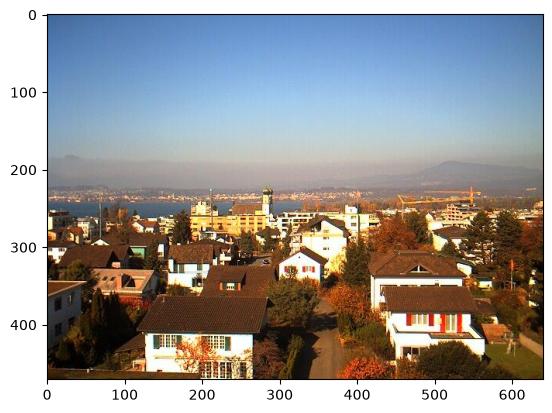

In [6]:
random_img_viz(all_img)


## Langkah 2 - Pra Pengolahan Data


In [7]:
def standarized_input(image):
    # resize to w: 1100, h: 600
    std_img = cv2.resize(image, (1100, 600))

    return std_img


In [8]:
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0

    if(label == 'day'):
        num_val = 1
    
    return num_val


In [9]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # Standarized the image
        std_img = standarized_input(image)

        # Create the label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))
    
    return std_img_list


In [10]:
std_img_list = preprocess(all_img)

# Random size checking
pick_random = np.random.randint(0, len(std_img_list))

print(f'Image {pick_random}')
print(std_img_list[pick_random][0].shape)


Image 17
(600, 1100, 3)


## Langkah 3 - Ekstraksi Fitur Histogram


In [11]:
# Ekstraksi fitur histogram pada setiap kanal warna (R, G, B)
def extract_histogram_feature(img, bins=32):
    hist_r = cv2.calcHist([img], [0], None, [bins], [0, 256])
    hist_g = cv2.calcHist([img], [1], None, [bins], [0, 256])
    hist_b = cv2.calcHist([img], [2], None, [bins], [0, 256])

    # Gabungkan histogram dan normalisasi
    hist = np.concatenate([hist_r, hist_g, hist_b]).flatten()
    hist = hist / hist.sum()

    return hist


In [12]:
# Tabulasi fitur histogram ke dalam dataframe
def extract_histogram_features(img_list, bins=32):
    features = []
    labels = []

    for img in img_list:
        img_hist = extract_histogram_feature(img[0], bins)
        img_label = img[1]

        features.append(img_hist)
        labels.append(img_label)

    df = pd.DataFrame(features)
    df['LABELS'] = labels

    return df


In [13]:
df = extract_histogram_features(std_img_list)
print(f'Shape: {df.shape}')
df.head()


Shape: (400, 97)


,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,LABELS
0,0.015627,0.124426,0.113346,0.033427,0.010666,0.005318,0.003721,0.003036,0.002470,0.002108,...,0.000032,0.000033,0.000030,0.000046,0.000039,0.000035,0.000035,0.000028,0.000010,0
1,0.000028,0.000105,0.000590,0.002560,0.005043,0.008569,0.012803,0.027013,0.038527,0.061715,...,0.000610,0.000581,0.000521,0.000523,0.000546,0.000735,0.001187,0.001846,0.000594,0
2,0.166112,0.039203,0.016377,0.009766,0.007246,0.006065,0.005487,0.005382,0.005693,0.006535,...,0.000345,0.000292,0.000255,0.000223,0.000206,0.000193,0.000213,0.000288,0.000891,0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002303,0.047989,0.045849,0.039057,...,0.000589,0.000510,0.000526,0.000533,0.000569,0.000615,0.000612,0.000680,0.001011,0
4,0.047485,0.087222,0.089690,0.083837,0.007003,0.003139,0.001823,0.001422,0.001089,0.000898,...,0.000206,0.000207,0.000199,0.000220,0.000242,0.000304,0.000381,0.000631,0.002022,0


## Langkah 4 - Split Data 80:20


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['LABELS'])
y = df['LABELS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Data latih:', X_train.shape)
print('Data uji:', X_test.shape)


Data latih: (320, 96)
Data uji: (80, 96)


## Langkah 5 - Model SVM Kernel RBF + Hyperparameter Tuning


In [15]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1]}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'C': 100, 'gamma': 1}
0.978125


## Langkah 6 - Evaluasi


In [16]:
from sklearn.metrics import accuracy_score

model = grid.best_estimator_

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')


Accuracy on train: 0.996875
Accuracy on test: 1.0


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred, target_names=['night', 'day']))


              precision    recall  f1-score   support

       night       1.00      1.00      1.00        40
         day       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

